# Comparision on query Level

In [1]:
import sys
import re
import matplotlib.pyplot as plt
import numpy as np
sys.path.append("../../..")
from utils.processing import json_file_access, evaluate
from beir.retrieval.evaluation import EvaluateRetrieval
from beir.datasets.data_loader import GenericDataLoader
from collections import defaultdict
from itertools import product

c:\Users\marvi\.conda\envs\masterthesis\Lib\site-packages\beir\datasets\data_loader.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
evaluator = EvaluateRetrieval()
corpus, queries, qrels = GenericDataLoader(data_folder="../../../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

  0%|          | 0/4635922 [00:00<?, ?it/s]

In [3]:
res_ir = json_file_access("../../../05_results/rq1/results_rq1.json","r")


results_rq1 = defaultdict(dict)

for key, value in res_ir.items():
    for query, result in value.items():
        results_rq1[key][query] = {}
        for i, (doc_id, score) in enumerate(result.items()):
            results_rq1[key][query][doc_id] = score

In [4]:
def differ_query_types(query):
    if query.startswith("INEX_LD"):
        return "INEX-LD"
    elif query.startswith("QALD2"):
        return "QALD-2"
    elif query.startswith("SemSearch_ES"):
        return "SemSearch ES"
    else:
        return "ListSearch"
    
query_types = {}
for key in queries.keys():
    query_type = differ_query_types(key)
    if query_type in query_types.keys() and isinstance(query_types[query_type], list):
        query_types[query_type].append(key)
    else:
        query_types[query_type] = [key]

def prepare_data_for_radar_plot(res_cs_ir_qtype, order):
    evaluation_dict = {}
    order_list = ["INEX-LD", "QALD-2","SemSearch ES","ListSearch"]

    for query_type in res_cs_ir_qtype.keys():
        evaluation_dict[query_type] = evaluate(res_cs_ir_qtype[query_type], [10,100], evaluator, qrels)
        evaluation_dict[query_type] = evaluation_dict[query_type].set_index('search_type').reindex(order_list).reset_index()
    return [evaluation_dict[ir_type] for ir_type in order]

def calc_radar_plot(dfs, category_col, value_col, order, title, save_path=None):
    """
    Parameters
    ----------
    dfs : list of pd.DataFrame
        A list of DataFrames. Each must contain a column for categories (labels)
        and another column for values.
    category_col : str
        Name of the column that contains category names.
    value_col : str
        Name of the column that contains numerical values.
    """
    # --------------------------------------------
    # 1. Consistency Check & Shared Categories
    # --------------------------------------------
    # We assume all DataFrames share the same categories in the same order.
    # If not, you'll need to handle the alignment or define a unified category list.
    categories = dfs[0][category_col].tolist()
    N = len(categories)

    # Create angle values for a full circle
    # Note that the first value is repeated at the end to close the polygon
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    # --------------------------------------------
    # 2. Create Radar Figure
    # --------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.spines["polar"].set_visible(False)

    # Set polar plot background details
    ax.set_theta_offset(np.pi / 2)      # Rotate the start so categories begin at the top
    ax.set_theta_direction(-1)         # Clockwise
    ax.set_thetagrids(angles[:-1] * 180 / np.pi, categories)  # Category labels

    # --------------------------------------------
    # 3. Plot Each DataFrame
    # --------------------------------------------
    # We'll choose colors here, but you can customize them
    colors = ['deepskyblue', 'darkorange', 'darkgreen', 'black']  # Enough for 4 DataFrames
    for i, (df, ir_type) in enumerate(zip(dfs,order)):
        # Retrieve the numerical values and repeat the first to close the polygon
        values = df[value_col].values
        values = np.concatenate((values, [values[0]]))
        if i == 3:
            ax.plot(angles, values, color=colors[i], linestyle = "dotted", linewidth=1, label=ir_type.upper())
        else:
            ax.plot(angles, values, color=colors[i], linewidth=1, label=ir_type.upper(), alpha=0.7)

    # --------------------------------------------
    # 4. Add Legend and Labels
    # --------------------------------------------
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.set_title(title, pad=20)

    # Show or save the figure
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


In [5]:
res_all = {}

configuration = {
    "cs_methods": ["LFMLocal", "GCE", "LocalTightnessExpansion"],
    "cs_core_node_number": [10,20,30]
}
# Iteratively add CS Top100
for cs in configuration["cs_methods"]:
    for cs_core_no in configuration["cs_core_node_number"]:
        res_all[cs + "_" + str(cs_core_no)] = json_file_access(f"../../../05_results/rq2/reranking/kg1_results_rq2_{cs}_{cs_core_no}_reranked.json","r")
res_all["RQ1" + "_" + str(0)] = json_file_access(f"../../../05_results/rq2/reranking/results_rq2_None_reranked.json","r")

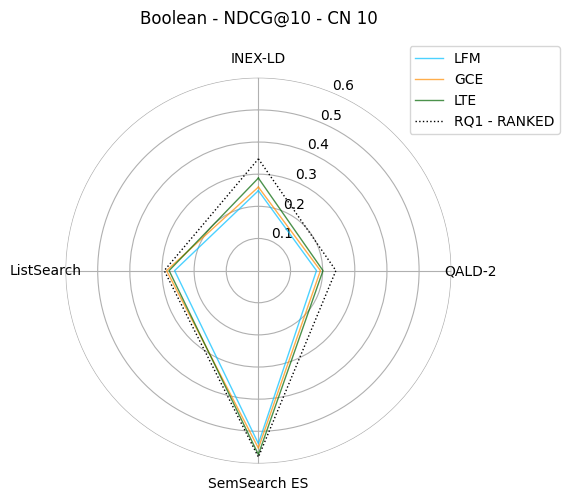

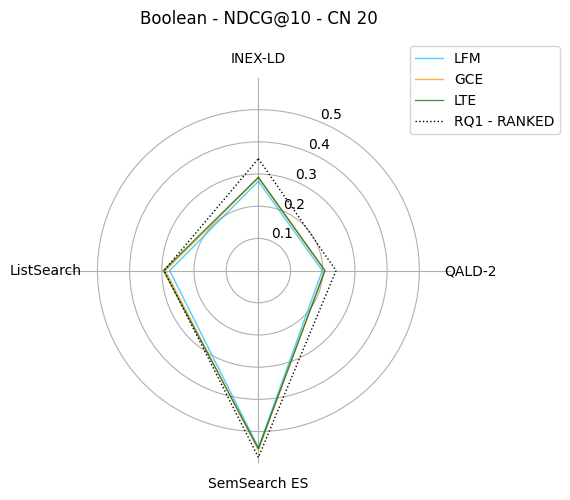

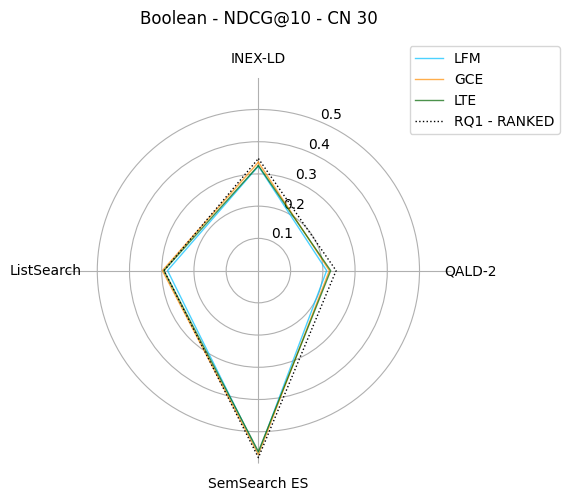

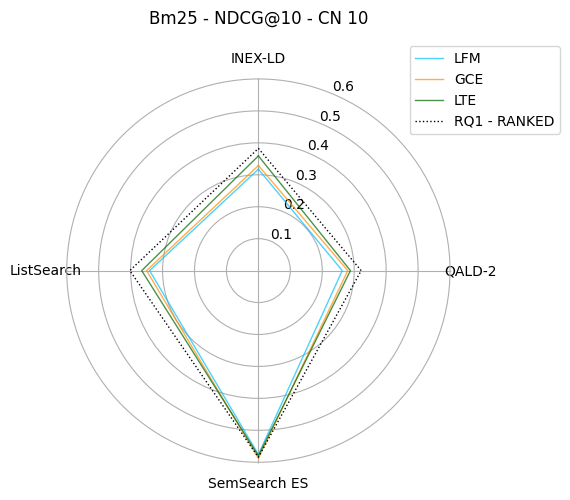

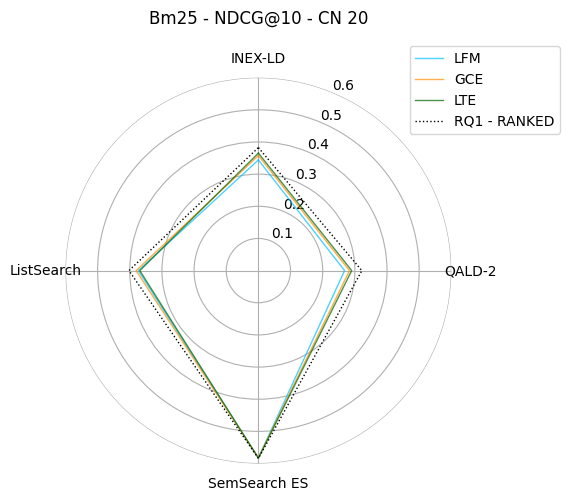

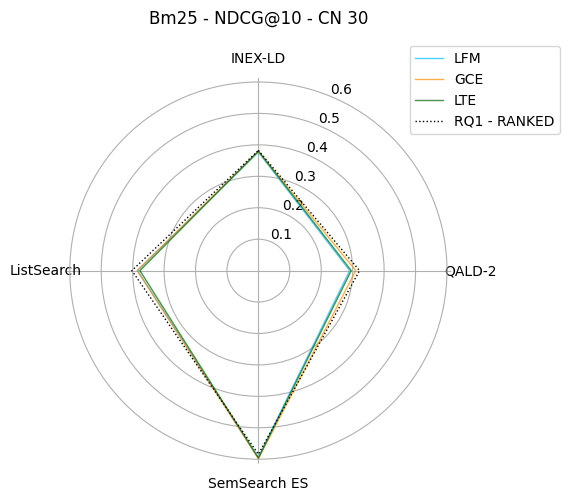

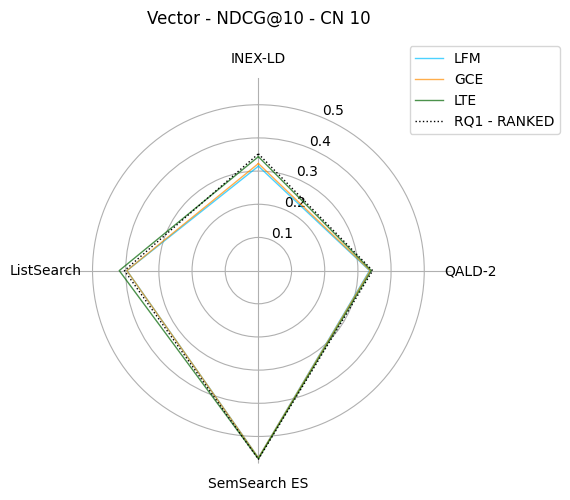

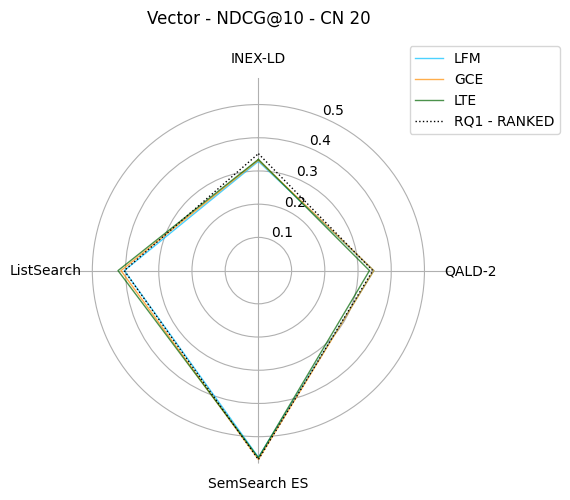

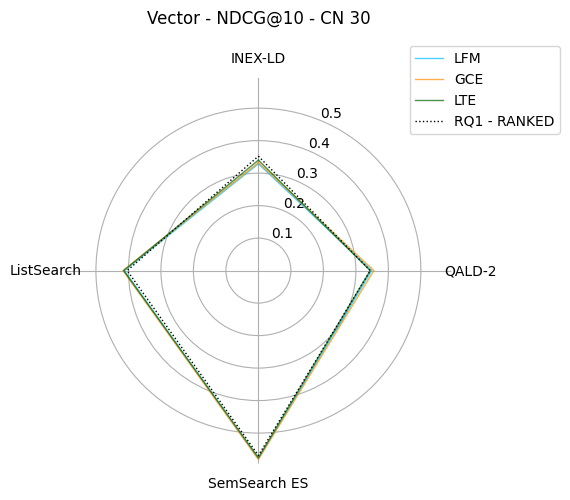

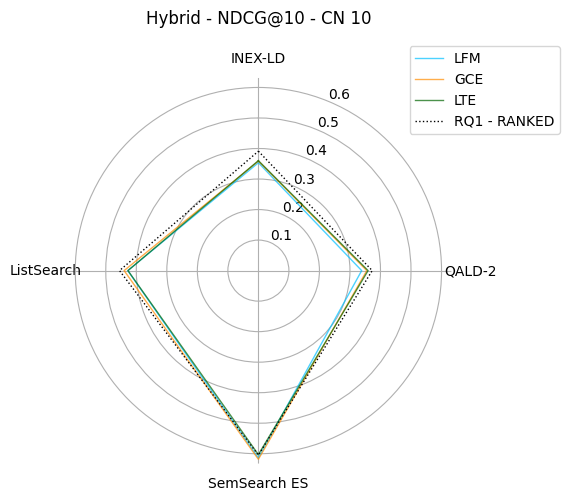

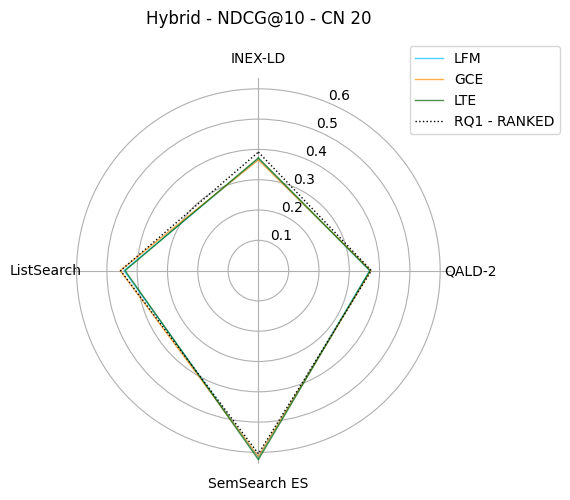

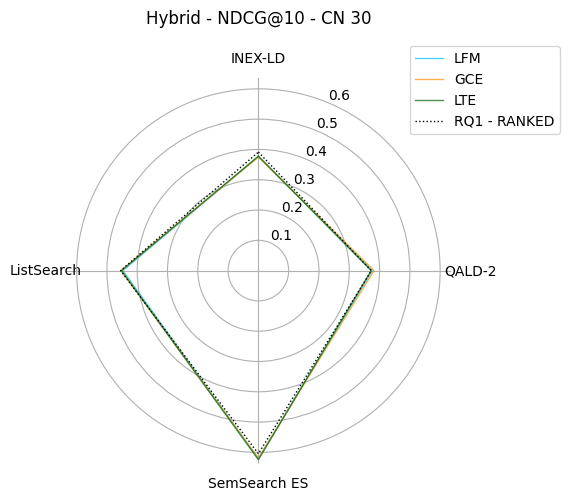

In [ ]:
# Abbildung 31 links sowie Anhang B16-B18
for ir_type, cn in product(["boolean","bm25","vector","hybrid"],[10,20,30]):

    order = []
    value_col = "NDCG@10"

    res_cs_ir_qtype = defaultdict(dict)
    for cs, cs_results in res_all.items():
        if cs.endswith(f"_{cn}") or cs.endswith("_0"):
            order.append(cs)
        else:
            continue
        for query_type in query_types.keys():
            res_cs_ir_qtype[cs][query_type] = {}
            for query in query_types[query_type]:
                if query == "SemSearch_ES-3":
                    continue
                res_cs_ir_qtype[cs][query_type][query] = res_all[cs][ir_type][query]
    dfs = prepare_data_for_radar_plot(res_cs_ir_qtype, order)

    calc_radar_plot(dfs, "search_type", value_col, ["LFM","GCE","LTE","RQ1 - Ranked"], f"{ir_type.title()} - {value_col} - CN {cn}", f"KG1_RQ2_Radar_{ir_type}_{value_col}_CS_{cn}.svg")

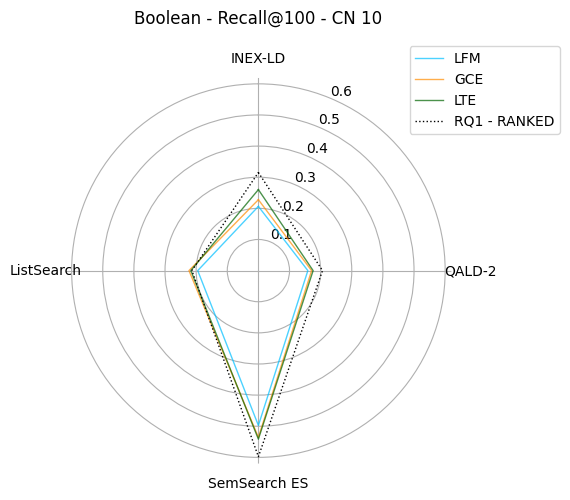

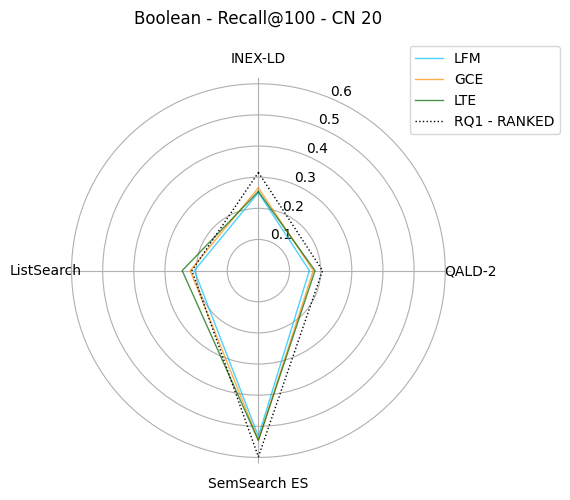

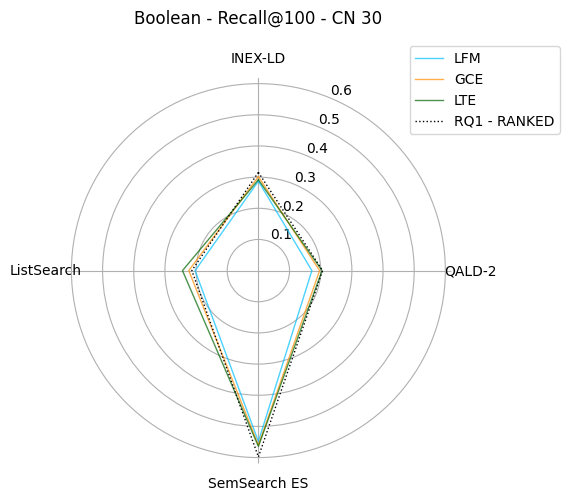

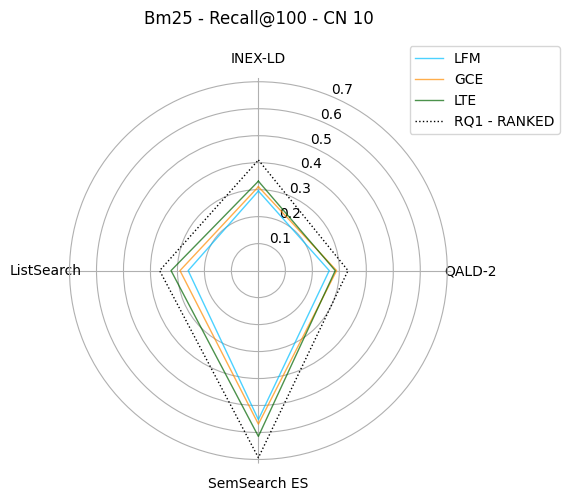

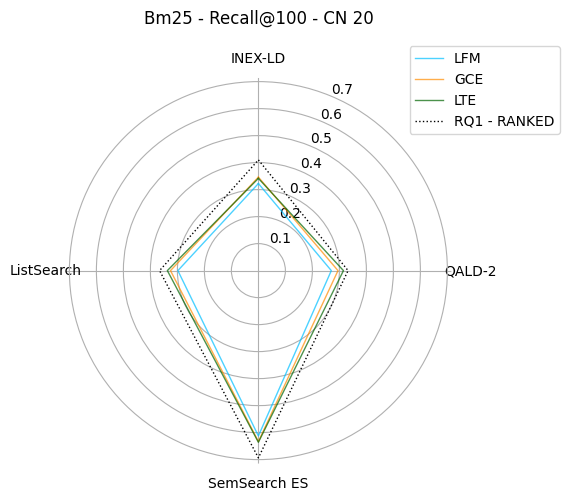

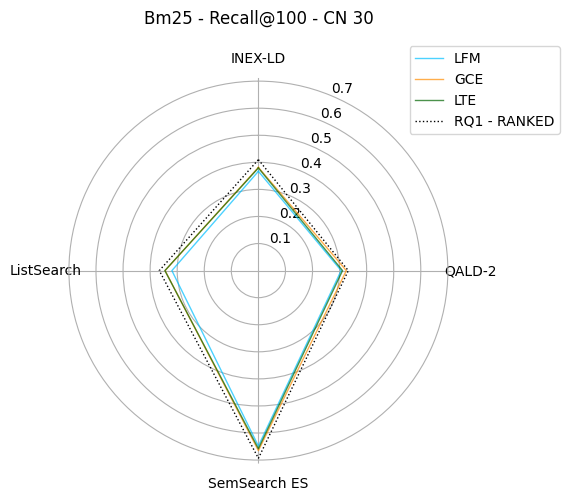

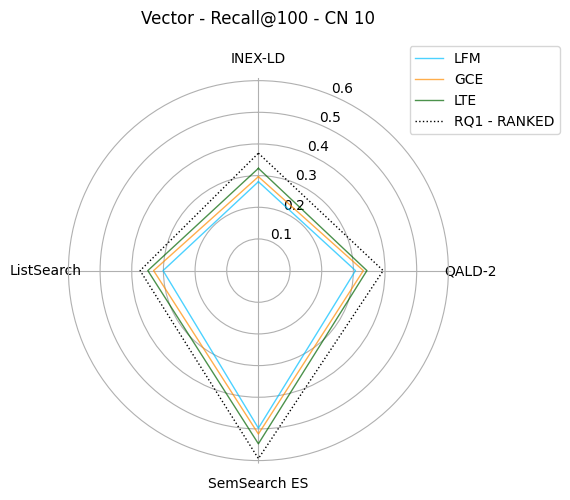

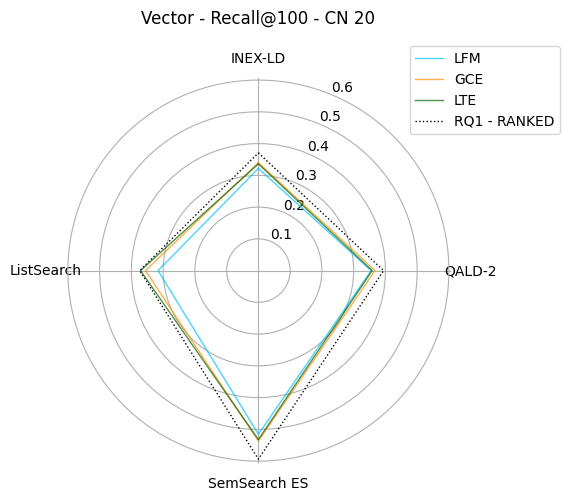

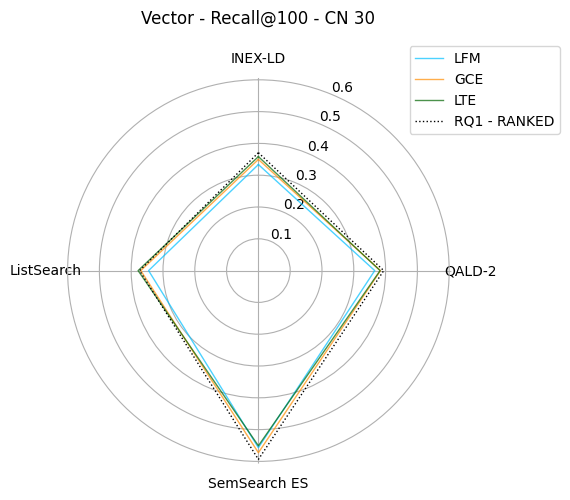

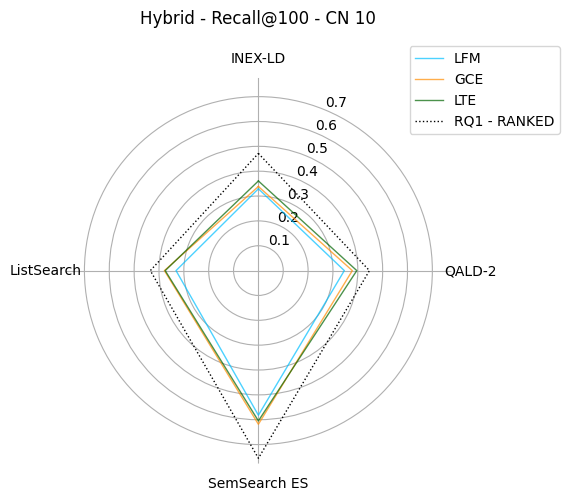

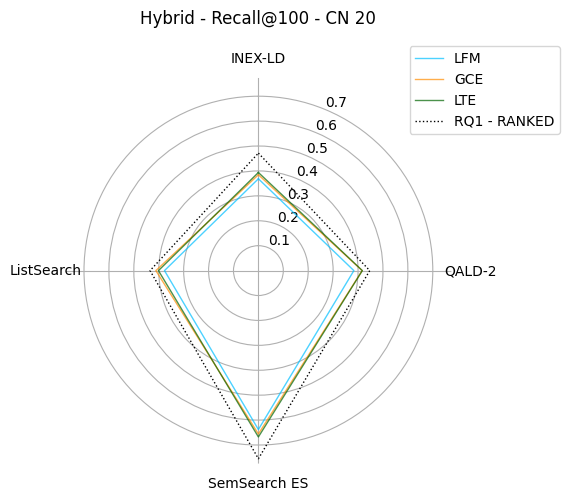

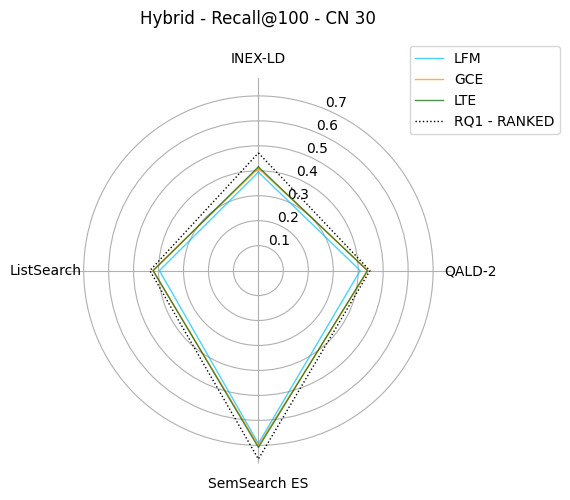

In [7]:
# Abbildung 31 rechts sowie Anhang B16-B7 rechts
for ir_type, cn in product(["boolean","bm25","vector","hybrid"],[10,20,30]):

    order = []
    value_col = "Recall@100"

    res_cs_ir_qtype = defaultdict(dict)
    for cs, cs_results in res_all.items():
        if cs.endswith(f"_{cn}") or cs.endswith("_0"):
            order.append(cs)
        else:
            continue
        for query_type in query_types.keys():
            res_cs_ir_qtype[cs][query_type] = {}
            for query in query_types[query_type]:
                if query == "SemSearch_ES-3":
                    continue
                res_cs_ir_qtype[cs][query_type][query] = res_all[cs][ir_type][query]
    dfs = prepare_data_for_radar_plot(res_cs_ir_qtype, order)

    calc_radar_plot(dfs, "search_type", value_col, ["LFM","GCE","LTE","RQ1 - Ranked"], f"{ir_type.title()} - {value_col} - CN {cn}", f"KG1_RQ2_Radar_{ir_type}_{value_col}_CS_{cn}.svg")